In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive

In [2]:
drive.mount('/content/drive')
df = pd.read_excel('/content/drive/My Drive/data_purch.xlsx')
print(f"Исходная таблица: {df.shape}")
print("Распределение")
print(df['is_abnd'].value_counts(normalize=True))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Исходная таблица: (556312, 22)
Распределение
is_abnd
0    0.502164
1    0.497836
Name: proportion, dtype: float64


In [3]:
df['duration_days'] = (pd.to_datetime(df['final_protocol_pub_date']) -
                      pd.to_datetime(df['collecting_end_date'])).dt.days
df['price_per_unit_log'] = np.log1p(df['drug_price'])
df['qty_price_ratio'] = df['drug_qty'] / (df['drug_position_price'] + 1)

In [4]:
features_pca = ['drug_qty', 'drug_price', 'drug_position_price', 'lot_price_correct']
scaler = StandardScaler()
features_scaled = scaler.fit_transform(df[features_pca].fillna(0))
pca = PCA(n_components=1)
df['pca_price_volume'] = pca.fit_transform(features_scaled).flatten()

In [5]:
agg_dict = {
    'is_abnd': 'max',
    'lot_price_correct': 'mean',
    'duration_days': 'mean',
    'price_per_unit_log': 'mean',
    'qty_price_ratio': 'mean',
    'pca_price_volume': 'mean',
    'is_znvlp': 'max',
    'is_narcotic': 'max',
    'is_msp_purchase': 'max',
    'is_povt': 'max',
    'is_dif': 'max',
    'app_amount_absolute_correct': 'mean',
    'advance_sum_correct': 'mean',
    'cust_reg': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown'
}

df_grouped = df.groupby('purchase_number').agg(agg_dict).reset_index()
print(f"\nГруппированная таблица: {df_grouped.shape}")


Группированная таблица: (166846, 15)


In [6]:
df_sample = df_grouped.sample(n=65000, random_state=42)
X = df_sample.drop(['purchase_number', 'is_abnd'], axis=1)
y = df_sample['is_abnd']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

X_train_enc = pd.get_dummies(X_train, columns=['cust_reg'])
X_test_enc = pd.get_dummies(X_test, columns=['cust_reg']).reindex(columns=X_train_enc.columns, fill_value=0)


Важные факторы
                             feature  importance
1                      duration_days    0.929757
4                   pca_price_volume    0.018943
3                    qty_price_ratio    0.005523
2                 price_per_unit_log    0.005407
0                  lot_price_correct    0.003875
50    cust_reg_Новосибирская область    0.003392
60  cust_reg_Республика Башкортостан    0.002973


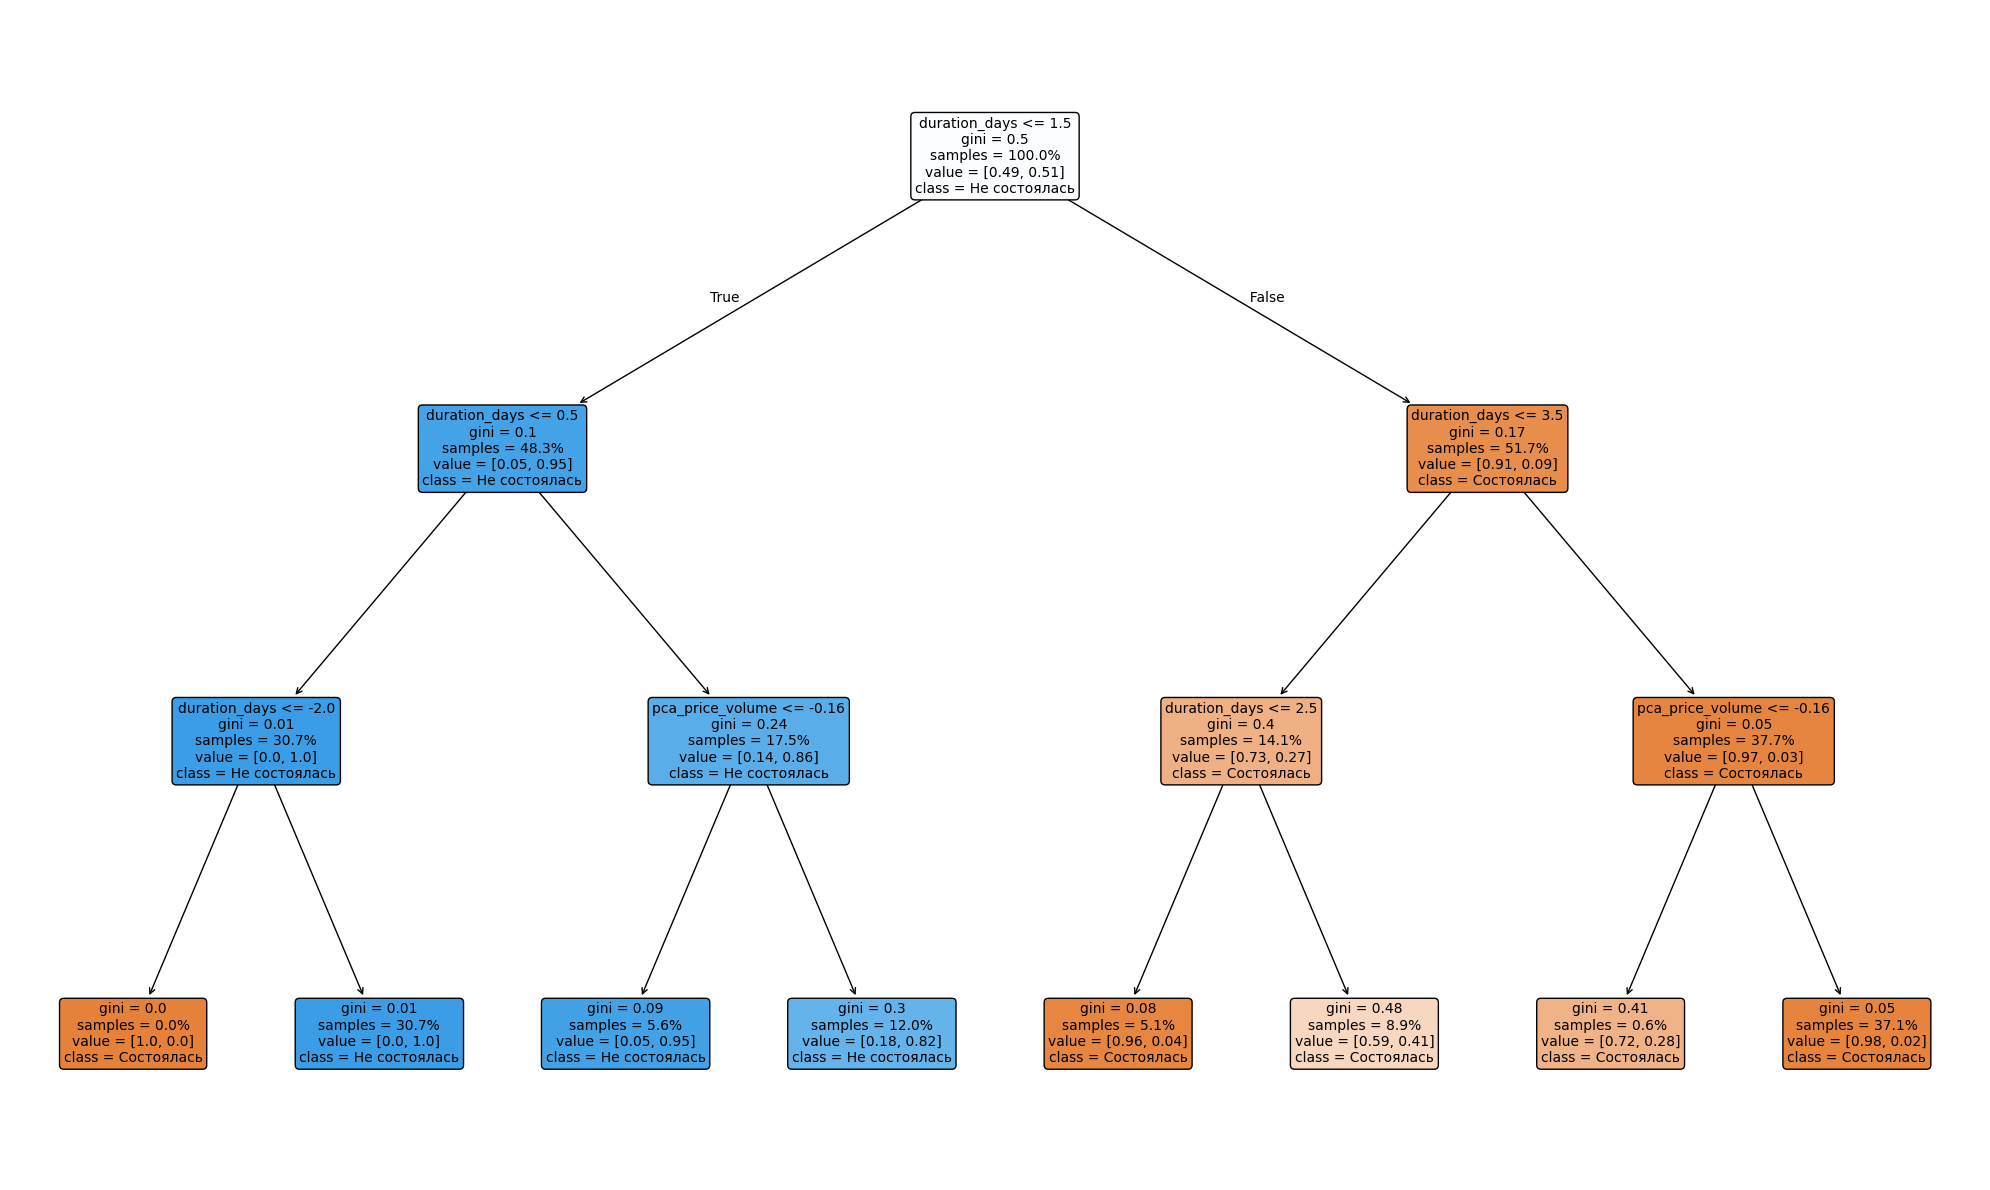

In [7]:
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train_enc, y_train)

importances = pd.DataFrame({
    'feature': X_train_enc.columns,
    'importance': dt.feature_importances_
}).sort_values('importance', ascending=False)

print("\nВажные факторы")
print(importances.head(7))

tree_for_plot = DecisionTreeClassifier(max_depth=3, random_state=42, min_samples_split=100)
tree_for_plot.fit(X_train_enc, y_train)

plt.figure(figsize=(20, 12))

plot_tree(tree_for_plot,
          feature_names=X_train_enc.columns.tolist(),
          class_names=['Состоялась', 'Не состоялась'],
          filled=True,
          rounded=True,
          fontsize=10,
          proportion=True,
          precision=2)

plt.tight_layout()
plt.show()

In [8]:
top_features = importances.head(7)['feature'].tolist()
X_train_final = X_train_enc[top_features].fillna(0)
X_test_final = X_test_enc[top_features].fillna(0)

X_train_final = X_train_final.dropna()
y_train = y_train.loc[X_train_final.index]

print(f"Размеры выборок: train {X_train_final.shape}, test {X_test_final.shape}")

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_final, y_train)

y_train_pred = lr.predict(X_train_final)
y_test_pred = lr.predict(X_test_final)

print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))
print(f"ROC-AUC (Test): {roc_auc_score(y_test, lr.predict_proba(X_test_final)[:,1]):.4f}")


Размеры выборок: train (55250, 7), test (9750, 7)
Train Accuracy: 0.8795
Test Accuracy:  0.8773

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.90      0.85      0.87      4820
           1       0.86      0.90      0.88      4930

    accuracy                           0.88      9750
   macro avg       0.88      0.88      0.88      9750
weighted avg       0.88      0.88      0.88      9750

ROC-AUC (Test): 0.9638
